![parcllabs](images/parcl_labs_logo.png)

# Real Time Real Estate Correlation Coefficients Notebook

Welcome to a Parcl Labs real time residential real estate correlation coefficient matrix notebook. 

Markets do not move in harmony with one another. In real time, we can understand the relationships of various housing markets across the country. 

Before we get started, make sure you have registered for the API, have obtained an API key, and are ready to get coding. 

For help on getting started with the API, please see:

- [Quickstart Guide](https://docs.parcllabs.com/docs/quickstart)
- [Quickstart Video](https://www.youtube.com/watch?v=E0nTxjfwY-g&t=84s)

In [ ]:
import os
import requests
from datetime import datetime, timedelta

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# grab your api key set as an environment variable
api_key = os.environ['parcl_labs_api_key']

headers = {
    "Authorization": api_key
}

# markets endpoint will provide all <parcls> available in the API currently
markets_endpoint = "https://api.realestate.parcllabs.com/v1/place/markets"

response = requests.get(markets_endpoint, headers=headers)

markets_json = response.json()


# select some interesting markets
pids = [
    5384169, # Atlanta
    5407714, # Boston
    5822447, # Brooklyn County
    5387853, # Chicago
    5306725, # Denver
    5377230, # Las Vegas
    5373892, # Los Angeles
    5352987, # Miami
    5353022, # Miami Beach
    5372594, # New York
    5378051, # Philly
    5386820, # Phoenix
    5408016, # Portland
    5374321, # San Fran
    5384705, # Seattle
    5503877, # Washington, DC
    5386838, # Scottsdale,
    2900332, # san diego
    2900398, # steamboat springs
    2900229, # palm bay FL
    2899841, # Charlotte
    2900174, # Nashville
    5306666, # CO Springs
    5290547, # Raleigh
    5333209, # Milwaukee
    5332726, # cinci
    5332800, # cleveland
    5328454, # new orleans
    5377717, # pittsburgh
    5307837, # jersey city
    5308252, # Lousiveille
]

# define data structure for custom collection of data elements
data = {}

for pid in pids:
    for v in markets_json:
        if v['parcl_id'] == pid:
            data[pid] = {'name': v['name'].replace('City', ''), 'state': v['state']}


# set start and end times for price feed with today being the max date
end = datetime.today().date()
dte_format = '%m/%d/%Y'
end_format = end.strftime(dte_format)

params = {
    'start': '1/1/2020',
    'end': end_format
}

dt = []
# grab the price feed and calculate percent change since time zero.
# in this case, time zero is 1/1/2020
for parcl_id in data.keys():
    price_feed_endpoint = f"https://api.realestate.parcllabs.com/v1/place/{parcl_id}/price_feed"    
    response = requests.get(price_feed_endpoint, params=params, headers=headers).json()
    price_feed = pd.DataFrame(response['price_feed'])
    price_feed = price_feed[['date', 'price']]
    price_feed.index = pd.DatetimeIndex(price_feed['date'])
    price_feed = price_feed.drop('date', axis=1)
    price_feed = price_feed.rename(columns={'price': data[parcl_id]['name']})
    dt.append(price_feed)
    
# concatenate all price feeds into one data structure
res = pd.concat(dt, axis=1)

Text(0.5, 1.0, 'Correlation Heatmap of Home Prices since 1/2020 (data as of 4/27/23)')

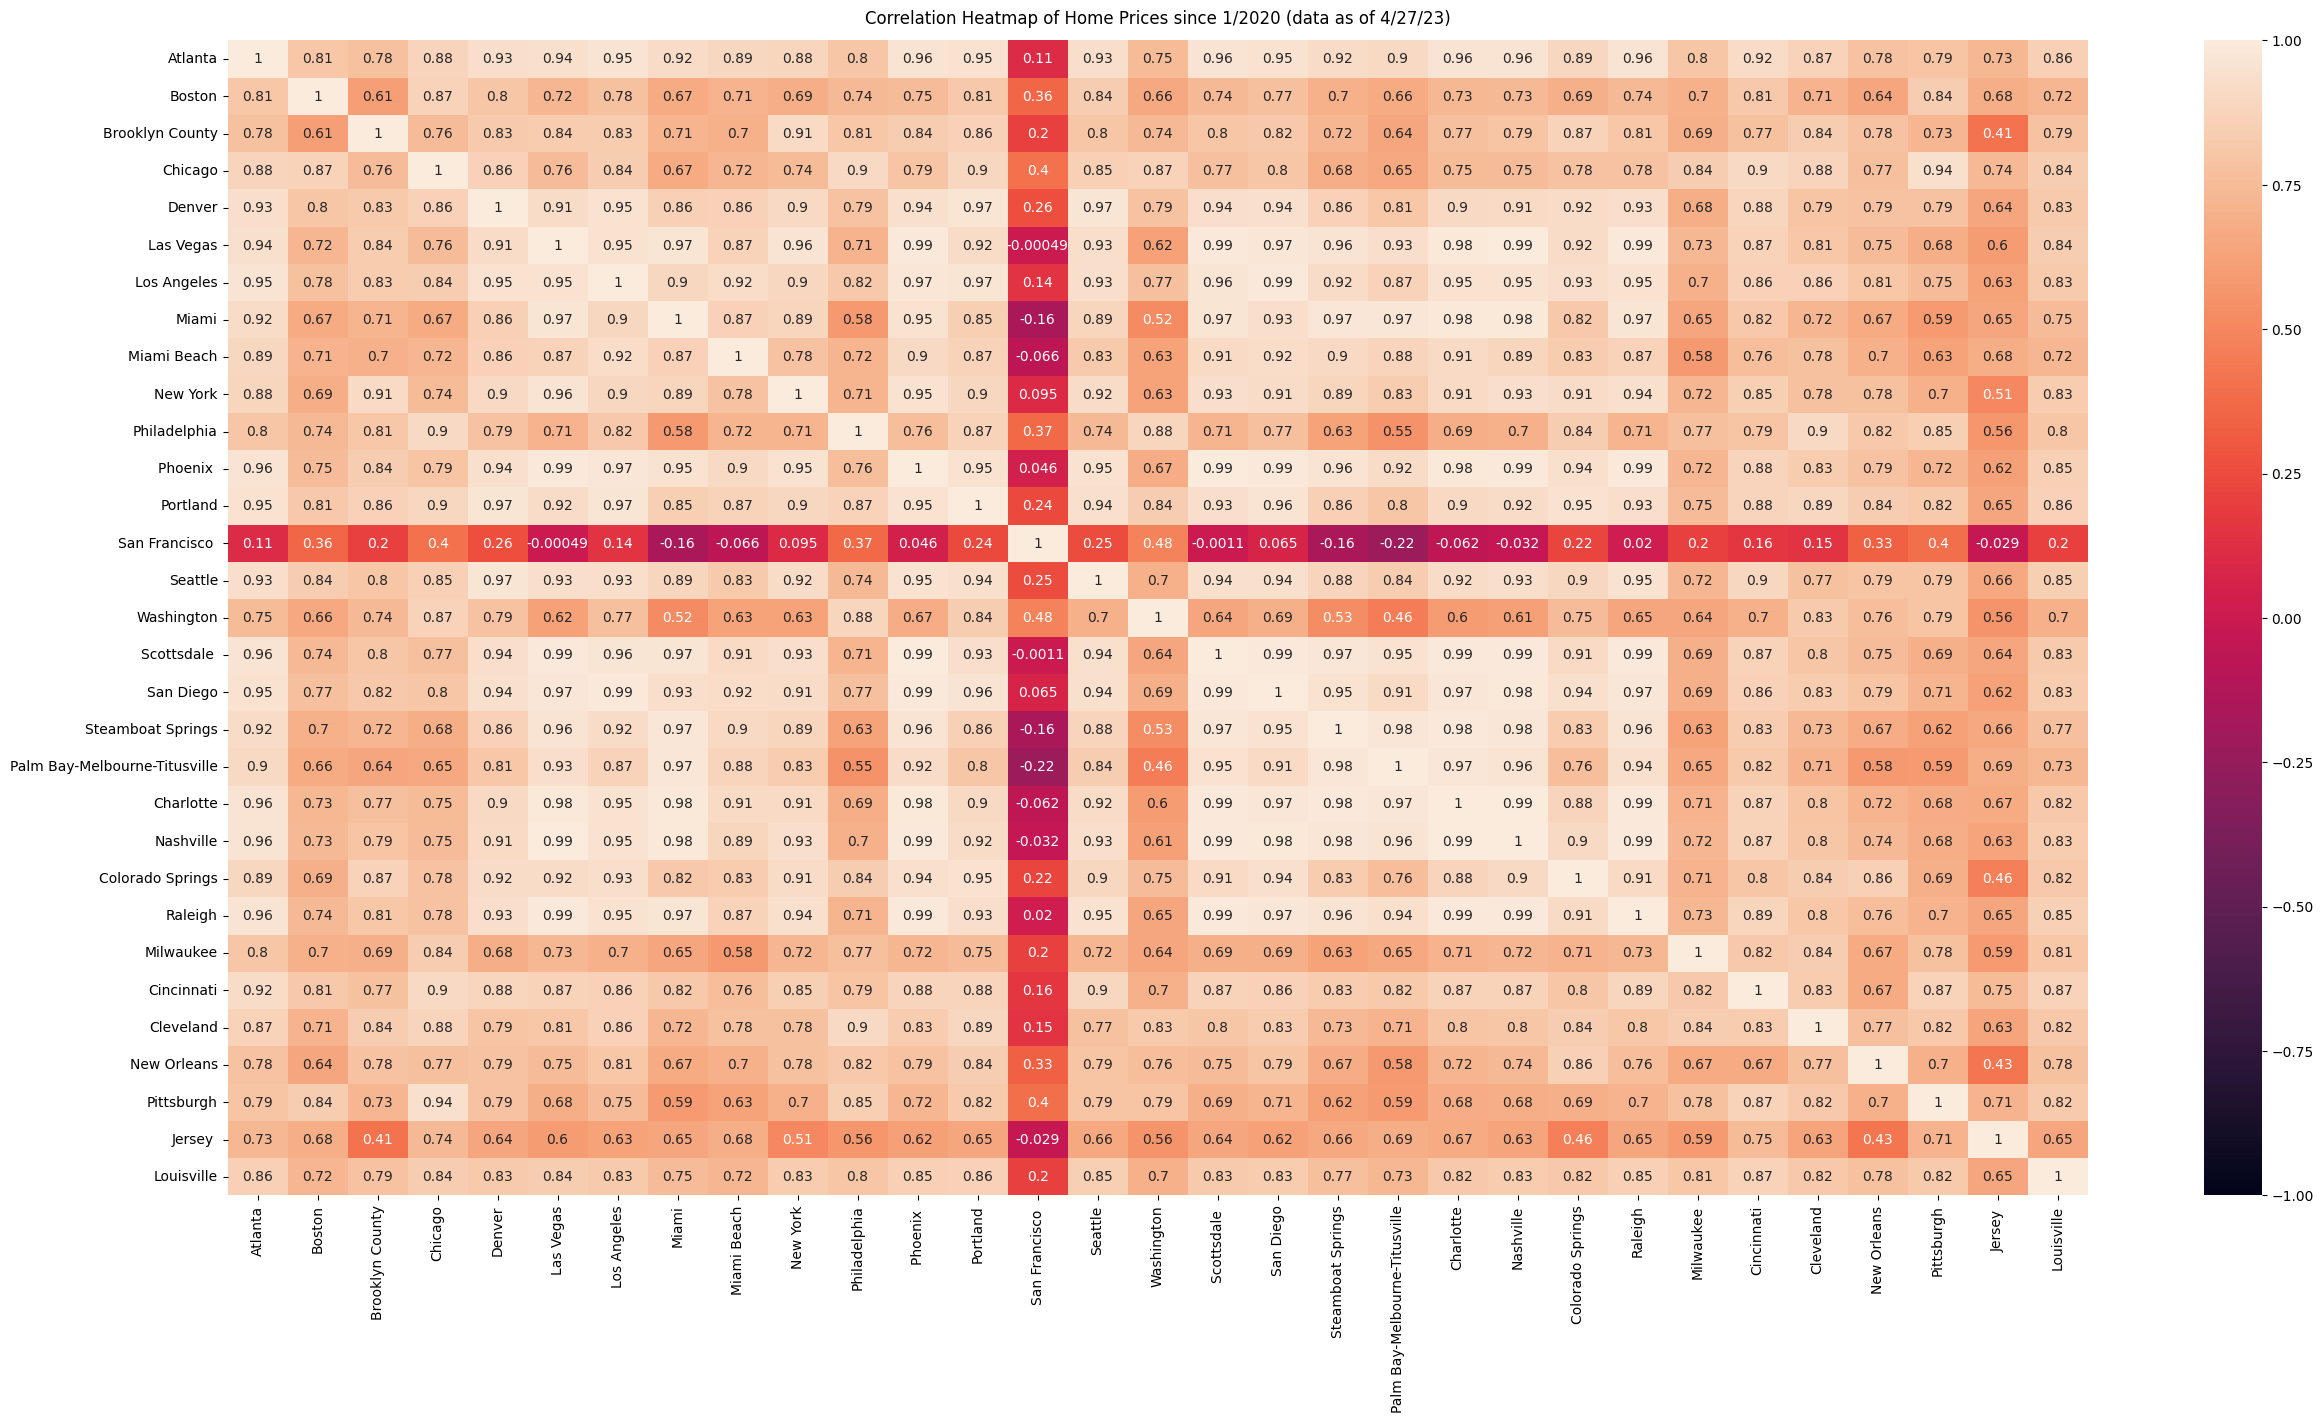

In [22]:
# create correlation coefficient matrix
plt.figure(
    figsize=(30, 15)
)

heatmap = sns.heatmap(
    res.corr(), 
    vmin=-1, 
    vmax=1, 
    annot=True
)

heatmap.set_title(
    'Correlation Heatmap of Home Prices since 1/2020 (data as of 4/27/23)', 
    fontdict={
        'fontsize':12
    }, 
    pad=12
)